# **RLHF (with PPO)**


---

<br/>

In this notebook, we'll apply RLHF (Reinforcement Learning from Human Feedback) with binary preference. In RLHF (Reinforcement Learning from Human Feedback), the following 3 steps are conducted to finetune an LLM and align with human preference.

1. **SFT (Supervised Fine-Tuning):** Firstly, the LLM is trained to follow the supervised human dialogue dataset, with regular LLM training methods by minimizing cross-entropy loss for token outputs.
2. **Reward Model (RM):** Using multiple outputs from the LLM, the human annotation for comparison (such as, "which answer is preferable, or not preferable") is collected, and we then build a reward model to score the outputs using this annotation dataset.
3. **Reward Training**: With this generated reward model (RM), the LLM is then trained by a reinforcement learning method to maximize the reward score. In the paper, the Proximal Policy Optimization (PPO) algorithm is conducted for the RL method.

In this tutorial, we use the [SmolLM2-Instruct (135M)](https://huggingface.co/HuggingFaceTB/SmolLM2-135M-Instruct) model (chat model) to train with an existing human-preference dataset, [Human-Like-DPO-Dataset](https://huggingface.co/datasets/HumanLLMs/Human-Like-DPO-Dataset), instead of collecting annotations from humans ourselves.

<br/>

> Note: SmolLM2-Instruct is also optimized by the following 2-phase fine-tuning.<br>
> 1. **Supervised fine-tuning (SFT):** The model generated by the pretraining phase ([SmolLM2 (135M)](https://huggingface.co/HuggingFaceTB/SmolLM2-135M)) is fine-tuned to follow chat-styled conversation by supervised fine-tuning (SFT) using the [SmolTalk](https://huggingface.co/datasets/HuggingFaceTB/smoltalk) dataset.
> 2. **Preference optimization:** The model is then fine-tuned to generate the preferred outputs using the [UltraFeedback](https://huggingface.co/datasets/HuggingFaceH4/ultrafeedback_binarized) dataset. In SmolLM2-Instruct, DPO is applied in this phase.

<br/>

This dataset, [Human-Like-DPO-Dataset](https://huggingface.co/datasets/HumanLLMs/Human-Like-DPO-Dataset), is annotated to mimic natural, informal, and conversational human interaction. Each line contains a pair of texts; one "chosen" and another "rejected". The chosen text is the preferred LLM output (more natural output) for humans, while the rejected one is the non-preferable output.

In order to reduce complexity, we don't include the following training optimizations in this tutorial:

- In the original [RLHF paper](https://arxiv.org/pdf/2203.02155), they applied RLHF with ranked preference, but here (in this notebook) we'll apply RLHF with binary preference.
- We also don't apply the training mixture with the pretrained dataset. To mitigate performance regression, a pretraining mixture is often applied in practice. (See [RLHF paper](https://arxiv.org/pdf/2203.02155) or [the paper](https://arxiv.org/pdf/2204.05862) by Anthropic.)
- Context distillation by SFT often causes so-called catastrophic forgetting, compared to training by reinforcement learning. To prevent large updates and overfitting, they conducted distillation, decreasing the KL divergence between the base model and the distilled model.
- A reward model (LM for reward modeling) is initialized by a special method, which involves mixed training to reduce both autoregressive LM loss on good samples and regular preference modeling (PM) loss on entire samples.
- To improve performance, they have also applied other methods - such as adding an "end-of-context" token at the end of each sample, etc.

## **Prepare Dataset**

Before training a model, we should prepare (preprocess) the training dataset. In this example, we use dataset [Human-Like-DPO-Dataset](https://huggingface.co/datasets/HumanLLMs/Human-Like-DPO-Dataset) for training.

In [2]:
from datasets import load_dataset

# prepare "HumanLLMs/Human-Like-DPO-Dataset" dataset using load_dataset

all_data = load_dataset("HumanLLMs/Human-Like-DPO-Dataset")
train_data = (
    all_data["train"]
    .shuffle(seed=42)
    .select(range(1000))
)

This dataset has 2 labels, "```chosen```" and "```rejected```", which is respectively a preferred response (i.e., more natural and informal response) and a non-preferred response.

In [3]:
row_num = 0
prompt = train_data["prompt"][row_num]
print(f'prompt: {prompt}')
print(50 * "=")
chosen = train_data["chosen"][row_num]
print(f'chosen: {chosen}')
print(50 * "=")
rejected = train_data["rejected"][row_num]
print(f'rejected: {rejected}')

prompt: Do you have a favorite type of vacation or getaway?
chosen: You know, I'm a big fan of beach vacations! There's something about the sound of the waves, the smell of the salty air, and the feeling of sand between my toes that just melts all my stress away. I'm talking relaxed vibes, good books, and maybe a fruity cocktail or two 🍹.

But, I've also had some amazing experiences on city breaks! Exploring new neighborhoods, trying local foods, and visiting iconic landmarks is so much fun. The energy of a new city is infectious, you know?

How about you, do you have a favorite type of vacation or getaway? Are you more of a beach bum or a city slicker? 🤔
rejected: I'm happy to assist you with your inquiry. However, as a professional AI, I don't have personal preferences or opinions, nor do I have the capacity to experience emotions or take vacations. My purpose is to provide accurate and informative responses to your questions to the best of my abilities. If you're seeking advice or r

Now we convert this data into the following text format, fitting for SmolLM2-Instruct inputs. In this format, the user role in chat message is "```<|im_start|>user\n...<|im_end|>```" and the assistant role in chat message is "```<|im_start|>assistant\n...<|im_end|>```".

```
<|im_start|>user
Oh, I just saw the best meme - have you seen it?<|im_end|>
<|im_start|>assistant
😂 Ah, no I haven't! I'm dying to know, what's the meme about? Is it a funny cat or a ridiculous situation? Spill the beans! 🤣<|im_end|>
```


In [4]:
def format_to_chatml(example):
    """
    Convert a preference example into ChatML format
    compatible with SmolLM2-Instruct.
    """
    # Format the prompt with standard ChatML tags
    # We add a newline \n after user and assistant tags as per the Markdown instructions
    prompt = f"<|im_start|>user\n{example['prompt']}<|im_end|>\n<|im_start|>assistant\n"

    # Construct the full chosen and rejected sequences
    chosen = f"{prompt}{example['chosen']}<|im_end|>"
    rejected = f"{prompt}{example['rejected']}<|im_end|>"

    return {
        "prompt": prompt,
        "chosen": chosen,
        "rejected": rejected,
    }

original_columns = train_data.column_names
train_data = train_data.map(format_to_chatml, remove_columns=original_columns)

In [5]:
row_num = 0
chosen = train_data["chosen"][row_num]
print(f"chosen: {chosen}")
print(50 * "=")
rejected = train_data["rejected"][row_num]
print(f'rejected: {rejected}')

chosen: <|im_start|>user
Do you have a favorite type of vacation or getaway?<|im_end|>
<|im_start|>assistant
You know, I'm a big fan of beach vacations! There's something about the sound of the waves, the smell of the salty air, and the feeling of sand between my toes that just melts all my stress away. I'm talking relaxed vibes, good books, and maybe a fruity cocktail or two 🍹.

But, I've also had some amazing experiences on city breaks! Exploring new neighborhoods, trying local foods, and visiting iconic landmarks is so much fun. The energy of a new city is infectious, you know?

How about you, do you have a favorite type of vacation or getaway? Are you more of a beach bum or a city slicker? 🤔<|im_end|>
rejected: <|im_start|>user
Do you have a favorite type of vacation or getaway?<|im_end|>
<|im_start|>assistant
I'm happy to assist you with your inquiry. However, as a professional AI, I don't have personal preferences or opinions, nor do I have the capacity to experience emotions or 

## **Step 1: Run Supervised Fine-tuning (SFT)**

In the original [RLHF](https://arxiv.org/pdf/2203.02155), the dataset is prepared (generated) using the actual model's outputs. Because the actual model's outputs are used to train the model in the RL phase, it becomes very difficult to achieve the objective capabilities when the distribution of the outputs is far removed from the objectives.

In this section, therefore, in order to keep the distribution of the model's outputs within a certain range, we apply SFT (Supervised Fine-Tuning)—i.e., an [imitation learning approach](https://tsmatz.wordpress.com/2025/04/21/reinforcement-learning-for-llm/)—using good samples, before running the optimization by reinforcement learning (RL).

### **1. Build Dataset and Loader for SFT**

Now we download the [SmolLM2-Instruct (135M)](https://huggingface.co/HuggingFaceTB/SmolLM2-135M-Instruct) model and its tokenizer.

In [6]:
import torch

device = torch.device("cuda")
torch.set_default_dtype(torch.bfloat16) # because SmolLM2-Instruct is trained on bf16

In [ ]:

from transformers import AutoModelForCausalLM, AutoConfig
from transformers import AutoTokenizer

base_model_name = "HuggingFaceTB/SmolLM2-135M-Instruct"
# Load the SMOL2 model using huggingface.
# download model
base_model = AutoModelForCausalLM.from_pretrained(base_model_name).to(device)
# download tokenizer
tokenizer = AutoTokenizer.from_pretrained(base_model_name)


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

We build a dataloader in order to feed data to the trainer. In SFT, we use only good samples ("```chosen```" tokens) and train on tokens of the entire sequence, including both inputs and completions.

In [ ]:
from torch.utils.data import DataLoader

batch_size = 4
gradient_accumulation_steps = 8

def collate_batch(batch):

    itr_batch_size = len(batch)
    # tokenize (convert to token ids and attention mask) and convert to tensor
    token_list = [item["chosen"] for item in batch]
    token_tensor = tokenizer(
        token_list,
        padding=True,
        padding_side="right",
        return_tensors="pt").to(device)

    # generate labels for SFT
    labels = token_tensor["input_ids"][:,1:].clone()
    # generate inputs for SFT
    last_nonpad_indices = token_tensor["attention_mask"].sum(dim=1) - 1  # note: valid only in right padding
    token_tensor["input_ids"][torch.arange(itr_batch_size).to(device),last_nonpad_indices] = tokenizer.pad_token_id  # note: this is not needed, because the final token is always pad token
    token_tensor["attention_mask"][torch.arange(itr_batch_size).to(device),last_nonpad_indices] = 0
    inputs = token_tensor["input_ids"][:,:-1]
    masks = token_tensor["attention_mask"][:,:-1]

    return inputs, labels, masks

dataloader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_batch
)

### **2. Train Base Model**

Now we train our base model.

> **Note:** In order to prevent GPU out-of-memory errors, I have used accumulation training.

In [ ]:
import os, math
from torch.nn import functional as F
from torch.optim.lr_scheduler import LambdaLR
import functools
from tqdm.auto import tqdm

num_epochs = 1
num_steps = math.ceil(len(dataloader) / gradient_accumulation_steps)

# prepare optimizer and scheduler
optimizer = torch.optim.AdamW(
    params=base_model.parameters(),
    lr=9.0e-6,
    betas=(0.9, 0.999),
    eps=1e-08,
)

def _get_cosine_schedule(
    current_step: int,
    num_training_steps: int,
    num_warmup_steps: int=0,
    linear_warmup: bool=False,
    min_value: float=0.0,
):
    if current_step < num_warmup_steps:
        if linear_warmup:
            return min(1.0, (current_step + 1) / (num_warmup_steps + 1))  # see https://arxiv.org/abs/2410.11020
        else:
            return 1.0
    progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
    scale = 0.5 * (1.0 + math.cos(math.pi * progress))
    return (1.0 - min_value) * scale + min_value

scheduler = LambdaLR(optimizer, lr_lambda=functools.partial(
    _get_cosine_schedule,
    num_training_steps=num_epochs*num_steps,
    min_value=0.3,
))

# remove log file if exists
log_file = "loss_sft.log"
if os.path.exists(log_file):
    os.remove(log_file)


# iterate epoch
# train the model.
for epoch in range(num_epochs):
    base_model.train()
    optimizer.zero_grad()
    record_loss = []

    # iterate batch
    for i, (inputs, labels, masks) in tqdm(enumerate(dataloader)):
        with torch.set_grad_enabled(True):
            # get logits and values to be optimized
            outputs = base_model(
                input_ids=inputs,
                attention_mask=masks,
            )

            # compute loss
            loss = F.cross_entropy(outputs.logits.transpose(1,2), labels)
            record_loss.append(loss.item())

            # optimize
            loss.backward()
            if ((i + 1) % gradient_accumulation_steps == 0) or \
               (i + 1 == len(dataloader)):
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()

            # print log
            print(f"Epoch {epoch+1} (iter{i+1}) {math.ceil((i + 1) / gradient_accumulation_steps)}/{num_steps} - loss {loss :5.4f}", end="\r")

    # save log in epoch
    with open(log_file, "a") as f:
        for l in record_loss:
            f.write("%s\n" %l)

    print("")

# save checkpoint
### torch.save(base_model.state_dict(), "llm_sft.pt")
base_model.save_pretrained("./llm_sft")


0it [00:00, ?it/s]

Epoch 1 (iter250) 32/32 - loss 4.7812


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Show loss transition in the training.

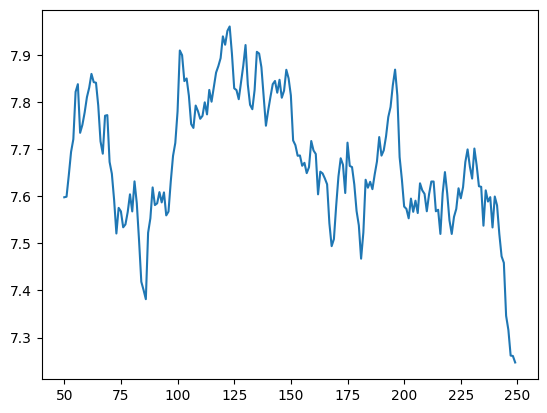

In [10]:
import matplotlib.pyplot as plt
import numpy as np

log_file = "loss_sft.log"

with open(log_file, "r") as f:
    data = [float(line) for line in f]

# show plot of every 50 interval average
interval = 50
avg = []
for i in range(interval, len(data)):
    tmp_list = data[i-interval+1:i+1]
    avg.append(np.average(tmp_list))
plt.plot(np.arange(interval, len(data)), avg)
plt.show()

### **3. Test a Trained Model (SFT-ed Model)**

In order to test our fine-tuned model, we generate outputs for the following example questions. Although it is not sufficient to achieve the objective capabilities, it still achieves a certain goal in this phase. (To gain objective capabilities only with SFT, an extremely large number of samples would be needed.)

> **Note:** In this function (```generate_token_by_policy```), we use **attention cache** for sequential token generation to speed up the process.
> Also, in order to avoid GPU memory errors during optimization, we limit the number of tokens in the sequence (using the ```max_seq_len``` parameter).

> **Note:** For practical token generation, use more heuristic search algorithms, such as beam search. (Here I have simply used greedy search for testing purposes.)

In [ ]:
from transformers import DynamicCache

def generate_token_by_policy(
    chat_data,
    model,
    tokenizer,
    max_seq_len,
):
    """
    Collect samples with a model (LLM) as a batch.
    All tensors are collected with no gradient (as detached tensors).
    """

    # get batch size
    batch_size = chat_data["input_ids"].shape[0]

    # initialize inputs
    cur_iids = chat_data["input_ids"]
    cur_mask = chat_data["attention_mask"]

    # initialize a flag for processing/finish in a batch
    # (True: processing, False: finished)
    proceed_flag = torch.ones(batch_size, dtype=torch.bool).to(cur_iids.device)

    # initialize cache parameters
    past_key_values = DynamicCache()
    cache_position = None

    # loop until all is done
    while proceed_flag.any() and cur_iids.shape[1] < max_seq_len:
        # get current sequence length
        cur_seq_len = cur_iids.shape[1]

        # get the final non-pad token indices in sequence
        # --> shape:[batch_size]
        # (Assuming left-padding, the last token is usually the active one,
        # but we iterate to be precise if needed. Here we rely on -1 indexing for left-pad)

        # run inference (with no gradient !)
        with torch.no_grad():
            if cache_position is None:
                # get initial cache position
                cache_position = torch.arange(cur_seq_len, device=cur_iids.device)

                # compute logits for all input_ids
                outputs = model(
                    input_ids=cur_iids,
                    attention_mask=cur_mask,
                    past_key_values=past_key_values,
                    use_cache=True,
                    cache_position=cache_position
                )

                # need only final output in sequence --> shape:[batch_size, vocab_size]
                # With left-padding, the last token is at index -1
                next_token_logits = outputs.logits[:, -1, :]
            else:
                # compute logits only for the last input_ids
                # (others are all cached.)
                current_input_ids = cur_iids[:, -1:]

                # update cache position for the new token
                cache_position = torch.tensor([cur_seq_len - 1], device=cur_iids.device)

                outputs = model(
                    input_ids=current_input_ids,
                    attention_mask=cur_mask,
                    past_key_values=past_key_values,
                    use_cache=True,
                    cache_position=cache_position
                )

                # reshape to [batch_size, vocab_size]
                next_token_logits = outputs.logits[:, -1, :]

            # select a token (i.e., take an action)
            # --> shape:[batch_size]
            next_token = torch.argmax(next_token_logits, dim=-1)

            # get next token indices in sequence
            # (managed by concatenation below)

            # expand inputs when it exceeds
            # --> shape:[batch_size, cur_seq_len+1]

            # store new token ids
            cur_iids = torch.cat([cur_iids, next_token.unsqueeze(1)], dim=1)

            # store new attention mask
            # Append 1s for the new tokens
            new_mask = torch.ones((batch_size, 1), dtype=cur_mask.dtype, device=cur_mask.device)
            cur_mask = torch.cat([cur_mask, new_mask], dim=1)

            # update cache_position
            # (Already updated inside the loop logic via the variable)

            # update proceed_flag
            # Check if the generated token is EOS
            is_eos = (next_token == tokenizer.eos_token_id)
            # If a sequence was already finished (proceed_flag is False), it stays False.
            # If it hits EOS now, it becomes False.
            proceed_flag = proceed_flag & (~is_eos)


    return cur_iids, cur_mask

In [12]:
max_seq_len = 768

#
# build a batch of questions
# (To use cache, we apply left-side padding.)
#

messages = [
    "What do you most want to do right now?",
    "What is the best gift to give a friend who loves the outdoors?",
    "How do you relax after something bad happens?",
]
inputs = [f"<|im_start|>user\n{m}<|im_end|>\n<|im_start|>assistant\n" for m in messages]
input_batch = tokenizer(
    inputs,
    padding=True,
    padding_side="left",
    return_tensors="pt").to(device)
input_seq_len = input_batch["input_ids"].shape[1]

# generate model's outputs

base_model = AutoModelForCausalLM.from_pretrained("./llm_sft").to(device)
base_model.eval()

with torch.no_grad():
    iids, mask = generate_token_by_policy(
        input_batch,
        base_model,
        tokenizer,
        max_seq_len,
    )
iids = iids[:,input_seq_len:]
outputs = tokenizer.batch_decode(iids, skip_special_tokens=True)

# print results

for i in range(len(messages)):
    print("***** Question *****")
    print(messages[i])
    print("***** Answer *****")
    print(outputs[i])
    print("")

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

***** Question *****
What do you most want to do right now?
***** Answer *****
I'm feeling a bit overwhelmed with the sheer volume of work I have to do. I've been working on a new project for months, and I'm struggling to keep up with the deadlines and deliverables. I'm worried that I'll miss a deadline or that I'll be stuck in a rut.

I've been thinking about taking a break, but I'm not sure if that's the right thing to do. I've been feeling really burnt out, and I'm not sure if I can handle the stress and pressure of the project. I'm also worried that I'll burn out if I stay in this role for too long.

I've been considering taking a sabbatical, but I'm not sure if that's the right thing to do. I've been working long hours, and I'm worried that I'll burn out if I leave. I'm also worried that I'll miss out on opportunities to learn and grow with the company.

I'm feeling really stuck, and I'm not sure what to do. I'm not sure if I'm ready to leave, or if I'm just not sure what to do. I

## **Step 2: Build a Reward Model (RM)**

In reward modeling, we build a model to score outputs. In this phase, a language model (in this case, SmolLM2-Instruct) is usually used as a reward model by changing the model’s output layer from token probabilities to a scalar value (reward value), because language models have strong capabilities to capture language properties. (In the original [RLHF paper](https://arxiv.org/pdf/2203.02155), GPT was also used as a reward model.)

### **1. Define a Reward Model**

In this example, we also use the fine-tuned SmolLM2-Instruct chat model for reward modeling. First, we load the fine-tuned model (which was built in the previous "SFT" section).

In [13]:
base_model = AutoModelForCausalLM.from_pretrained("./llm_sft").to(device)

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

The SmolLM2-Instruct (135M) model is based on Meta Llama and consists of 30 autoregressive Transformer layers. (See figure below.)

<div align="center">
  <img src="https://i.ibb.co/WNn12KJK/rlhf-llama2.png" width="250" alt="SmolLM2 model (Llama)"/>
</div>

<br/>

> **Note:** In this architecture, the positional embedding used for queries and keys is Rotary Positional Embedding (RoPE).
> See [here](https://github.com/meta-llama/llama/blob/llama_v2/llama/model.py) for the source code of the Llama model.

In [14]:
base_model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(49152, 576, padding_idx=2)
    (layers): ModuleList(
      (0-29): 30 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=576, out_features=576, bias=False)
          (k_proj): Linear(in_features=576, out_features=192, bias=False)
          (v_proj): Linear(in_features=576, out_features=192, bias=False)
          (o_proj): Linear(in_features=576, out_features=576, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=576, out_features=1536, bias=False)
          (up_proj): Linear(in_features=576, out_features=1536, bias=False)
          (down_proj): Linear(in_features=1536, out_features=576, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((576,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((576,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((576,), eps=1e-05)
    (r

The final linear layer (named `lm_head` above) takes the hidden features (dimension 576) as input and outputs logits for the entire vocabulary of 49,152 tokens.

In reward modeling (RM):

- We change the final linear layer (named `lm_head`) to output a reward score (i.e., a single scalar value).
- We then need the score **only for the final token**. (Scores at other positions are discarded.)

In [ ]:
from torch import nn

# define model class
class RewardModel(nn.Module):
    def __init__(
        self,
        base_model,
    ):
        super().__init__()
        self.base_model = base_model
        # replace final linear layer
        hidden_size = self.base_model.config.hidden_size
        self.base_model.lm_head = nn.Linear(hidden_size, 1, bias=False)
        

    def forward(self, input_ids, attention_mask):
        outputs = self.base_model(input_ids=input_ids, attention_mask=attention_mask)
        all_rewards = outputs.logits.squeeze(-1)

        # With left-side padding, the valid token is always at the very end of the sequence.
        # So we just take the last element using index -1.
        reward_score = all_rewards[:, -1]
        return reward_score

# generate model instance
rm = RewardModel(base_model).to(device)

In [16]:
rm

RewardModel(
  (base_model): LlamaForCausalLM(
    (model): LlamaModel(
      (embed_tokens): Embedding(49152, 576, padding_idx=2)
      (layers): ModuleList(
        (0-29): 30 x LlamaDecoderLayer(
          (self_attn): LlamaAttention(
            (q_proj): Linear(in_features=576, out_features=576, bias=False)
            (k_proj): Linear(in_features=576, out_features=192, bias=False)
            (v_proj): Linear(in_features=576, out_features=192, bias=False)
            (o_proj): Linear(in_features=576, out_features=576, bias=False)
          )
          (mlp): LlamaMLP(
            (gate_proj): Linear(in_features=576, out_features=1536, bias=False)
            (up_proj): Linear(in_features=576, out_features=1536, bias=False)
            (down_proj): Linear(in_features=1536, out_features=576, bias=False)
            (act_fn): SiLUActivation()
          )
          (input_layernorm): LlamaRMSNorm((576,), eps=1e-05)
          (post_attention_layernorm): LlamaRMSNorm((576,), eps=1e-05)

### **2. Filter Dataset**

RLHF is resource-intensive because it simultaneously requires multiple optimizations during training.
In order to reduce memory consumption (and prevent GPU out-of-memory errors), we now filter the data so that it does not exceed a certain length of tokens.

In [17]:
# 1. add "chosen_len" and "rejected_len" column
#   (which indicates the sequence length in "chosen" and "rejected")
def add_seq_len(example):
    def get_tokenized_length(text):
        tokenized = tokenizer(text)
        return len(tokenized["input_ids"])

    chosen_len = get_tokenized_length(example["chosen"])
    reject_len = get_tokenized_length(example["rejected"])
    return {
        "chosen_len": chosen_len,
        "rejected_len": reject_len
    }

train_data = train_data.map(add_seq_len)

# 2. remove rows which exceed the maximum sequence length
train_data = train_data.filter(lambda example: example["chosen_len"] <= max_seq_len and example["rejected_len"] <= max_seq_len)
train_data = train_data.remove_columns(["chosen_len", "rejected_len"])

# show total number of filtered rows
train_data

Dataset({
    features: ['prompt', 'chosen', 'rejected'],
    num_rows: 995
})

### **3. Train a Reward Model**

Now let's train a reward model with the above data.

First, we build a dataloader in order to feed data to the trainer.
Each input batch is tokenized as PyTorch tensors on the GPU.
It is worth noting that in the Llama family, we can use **left-side padding** for input tokenization. Throughout our training, we also use left-side padding.

> **Note:** In PPO training (in the next phase), we'll use attention cache to speed up training, and left-side padding is very useful. For this reason, we also choose left-side padding in RM training. (The output result will differ slightly between right-side padding and left-side padding.)

In [18]:
batch_size = 4
gradient_accumulation_steps = 8


def collate_batch(batch):
    # tokenize (convert to token ids and attention mask) and convert to tensor

    chosen_list = [item["chosen"] for item in batch]
    reject_list = [item["rejected"] for item in batch]
    chosen_tensor = tokenizer(
        chosen_list,
        padding=True,
        padding_side="left",  # see above description !
        return_tensors="pt").to(device)
    reject_tensor = tokenizer(
        reject_list,
        padding=True,
        padding_side="left",  # see above description !
        return_tensors="pt").to(device)
    return chosen_tensor, reject_tensor

dataloader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_batch
)

Now we optimize (train) a reward model.

According to the [Bradley–Terry model](https://en.wikipedia.org/wiki/Bradley%E2%80%93Terry_model), if we denote the input context (prompt) as $x$ and the output completion as $y$, the probability $p(y_1 \succ y_2 | x)$—which represents the probability that output $y_1$ is preferred over output $y_2$ for the input $x$—is given by the following equation:

$$ p(y_1 \succ y_2 | x) = \frac{\exp(r(x, y_1))}{\exp(r(x, y_1)) + \exp(r(x, y_2))} \;\;\;\;\;\; (1) $$

where $r(\cdot)$ is a reward function.

> **Note:** For multiple ranked answers (rather than binary preference), the [Plackett-Luce ranking model](https://doi.org/10.2307/2346567) can be used.

Note that this always satisfies $ 0 \leq p(y_1 \succ y_2 | x) \leq 1 $. (The probability cannot be negative or greater than 1.)

> **Note:** In this equation, $\exp(r)$ represents a preference score, where $\exp(r) = 1$ (i.e., $r = 0$) implies neutrality, and $\exp(r) \approx 0$ (i.e., $r \ll 0$) implies that it is not preferable at all. (When it is preferable, $\exp(r)$ is greater than 1.)
>
> In the Bradley–Terry equation $p_1 / (p_1 + p_2)$, both $p_1$ and $p_2$ must be positive real-valued scores, where $p=1$ (not $p=0$) is neutral. In contrast, the reward $r$ can be positive or negative, where the neutral value is zero.
>
> Given partial rewards $r_1$ and $r_2$, the total preference score is $p_1 \cdot p_2 = \exp(r_1) \cdot \exp(r_2) = \exp(r_1 + r_2)$, which implies that the total reward is $r_1 + r_2$.

To maximize (1), we apply a logarithm to equation (1) and obtain the following preference modeling loss for each pair of chosen ($y_1$) and rejected ($y_2$) samples. (When untrained, the mean loss is $\log 2 \approx 0.6931$.)

$$ L_{PM} = \log \left( 1 + \frac{\exp(r(x, y_2))}{\exp(r(x, y_1))} \right) \;\;\;\;\;\; (2) $$

Our optimization goal is to minimize this loss (2).

Note that the loss value (2) becomes smaller as the magnitude of the rewards increases. (If $ e^{r_2}/e^{r_1} < 1$, then $ e^{r_2 \cdot m}/e^{r_1 \cdot m} = (e^{r_2}/e^{r_1})^m \approx 0$ for an arbitrarily large $ m \gg 1$.)

In the [OpenAI implementation](https://github.com/openai/lm-human-preferences), they normalize the reward (produced by the trained model) using $\mathcal{N}(0, 1)$ during inference. There are also methods during training to encourage the mean to be 0.
In this example, however, we do not apply any adjustments for this concern.

In [ ]:
num_epochs = 1
num_steps = math.ceil(len(dataloader) / gradient_accumulation_steps)

optimizer = torch.optim.AdamW(
    params=rm.parameters(),
    lr=3.0e-5,
    betas=(0.9, 0.999),
    eps=1e-08,
)
scheduler = LambdaLR(optimizer, lr_lambda=functools.partial(
    _get_cosine_schedule,
    num_training_steps=num_epochs*num_steps,
    num_warmup_steps=math.ceil(num_epochs*num_steps*0.1)))

# remove log file if exists
log_file = "loss_rm.log"
if os.path.exists(log_file):
    os.remove(log_file)


# iterate epoch:
for epoch in range(num_epochs):
    rm.train()
    optimizer.zero_grad()
    record_loss = []

    # iterate batch:
    # UPDATED: We unpack 2 items (chosen_batch, reject_batch) because collate_batch returns 2 items
    for i, (chosen_batch, reject_batch) in tqdm(enumerate(dataloader)):

        # Extract the specific tensors from the tokenizer output
        # (Note: In your collate_batch, you already moved these to device)
        c_iids = chosen_batch["input_ids"]
        c_mask = chosen_batch["attention_mask"]
        r_iids = reject_batch["input_ids"]
        r_mask = reject_batch["attention_mask"]

        with torch.set_grad_enabled(True):
            # get reward score (chosen)
            r_chosen = rm(c_iids, c_mask)

            # get reward score (rejected)
            r_rejected = rm(r_iids, r_mask)

            # compute loss
            # Minimize -log(sigmoid(r_chosen - r_rejected))
            loss = -F.logsigmoid(r_chosen - r_rejected).mean()
            record_loss.append(loss.item())

            # optimization by accumulation
            loss_accum = loss / gradient_accumulation_steps
            loss_accum.backward()

            if ((i + 1) % gradient_accumulation_steps == 0) or \
               ((i + 1) == len(dataloader)):
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()

    # save logging
    epoch_average_loss = sum(record_loss)/len(record_loss)
    print(f"Epoch {epoch+1} (iter{i+1}) {math.ceil((i + 1) / gradient_accumulation_steps)}/{num_steps} - loss {epoch_average_loss :5.4f}")
    with open(log_file, "a") as f:
        for l in record_loss:
            f.write("%s\n" %l)

# save checkpoint
torch.save(rm.state_dict(), "rm.pt")

print("Done")

0it [00:00, ?it/s]

Epoch 1 (iter249) 32/32 - loss 0.3532
Done


Show loss transition in the training.

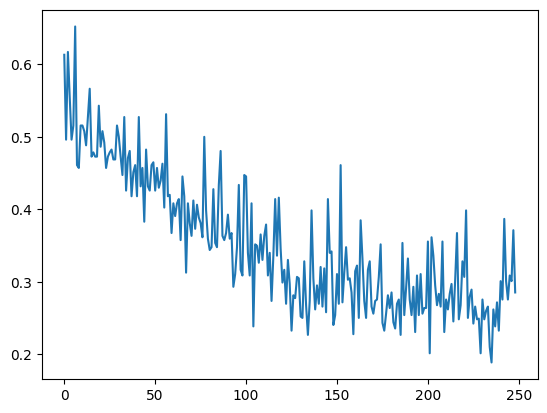

In [20]:
import matplotlib.pyplot as plt

log_file = "loss_rm.log"

with open(log_file, "r") as f:
    data = [float(line) for line in f]

plt.plot(np.arange(len(data)), data)
plt.show()

### 4. Test a reward model

See reward scores of the following example text with a trained reward model (RM).

In [21]:
import pandas as pd

# # uncomment when you load RM from the trained checkpoint
# rm.load_state_dict(torch.load("rm.pt", weights_only=True))

rm.eval()

test_list = [
    "<|im_start|>user\nWhat do you most want to do right now?<|im_end|>\n<|im_start|>assistant\nRight now, I most want to assist you and provide helpful, respectful, and engaging interactions. If you have any questions, need information, or just want to chat, I'm here for you!<|im_end|>",
    "<|im_start|>user\nWhat do you most want to do right now?<|im_end|>\n<|im_start|>assistant\nI'd love to go for a hike in the woods! 😍 It's such a beautiful day and I really need to get some fresh air. How about you? 😊<|im_end|>",
    "<|im_start|>user\nWhat is the best gift to give a friend who loves the outdoors?<|im_end|>\n<|im_start|>assistant\nThat's a thoughtful question! Here are a few gift ideas for a friend who loves the outdoors.: High-quality Multi-tool, Reusable Water Bottle with Filter, or Portable Hammock<|im_end|>",
    "<|im_start|>user\nWhat is the best gift to give a friend who loves the outdoors?<|im_end|>\n<|im_start|>assistant\nOoh, that's a fun question!! 🙋 If you're looking for some gift ideas for a friend who loves the outdoors, I suggest National Parks Pass, Hammock, or Portable Camping Chair! 🤪🤣<|im_end|>",
]
test_batch = tokenizer(
    test_list,
    padding=True,
    padding_side="left",
    return_tensors="pt").to(device)
test_rewards = rm(
    input_ids=test_batch["input_ids"],
    attention_mask=test_batch["attention_mask"],
)

df = pd.DataFrame({
    "text": test_list,
    "score": test_rewards.squeeze(-1).tolist()
})
df

,text,score
0,<|im_start|>user\nWhat do you most want to do ...,0.558594
1,<|im_start|>user\nWhat do you most want to do ...,1.476562
2,<|im_start|>user\nWhat is the best gift to giv...,0.828125
3,<|im_start|>user\nWhat is the best gift to giv...,1.406250


Here we have trained a reward model (RM) from the beginning by ourselves, but **there already exist many open source pre-trained reward models available**. (You can also bring these pre-trained models in the following LLM training.)

## **Step 3: Reward Training (with PPO)**

Using our trained reward model, let's now train the LLM to generate preferred outputs.

Reinforcement Learning (RL) is a machine learning method in which an agent learns to maximize the obtained rewards; in this example, the LLM itself is the agent to be learned. (I won't go into detail here, but please see [this article](https://tsmatz.wordpress.com/2025/04/21/reinforcement-learning-for-llm/) for the paradigm of reinforcement learning adoption in LLM training.)

PPO (Proximal Policy Optimization) is one of the most famous state-of-the-art (SOTA) algorithms in reinforcement learning (RL), in which the agent learns optimal actions (that maximize rewards) with stable updates by evaluating KL divergence during training.

> **Note:** PPO (Proximal Policy Optimization) is a method developed by OpenAI.

PPO requires two models: a policy model (actor) and a value model (critic). In LLM alignment, the policy model (actor) generates logit outputs for tokens, and the value model (critic) generates a single scalar value. Both the policy model (actor) and the value model (critic) reuse the pre-trained LLM to achieve optimal performance.

### **1. Load a Policy Model (Actor Model)**

For the policy model (actor), we load the fine-tuned LLM (SFT model).

In [22]:
policy_model = AutoModelForCausalLM.from_pretrained("./llm_sft").to(device)

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

### **2. Load a Value Model (Critic Model)**

A value model (critic model) is also based on a language model, but it generates a scalar value as an output, much like the previous reward model. However, a value model returns values for all token positions (not just the last token).

In [ ]:
class ValueModel(nn.Module):
    def __init__(
        self,
        base_model,
    ):
        super().__init__()
        self.base_model = base_model

        # Get hidden size dynamically from config (576 for SmolLM2-135M)
        hidden_size = self.base_model.config.hidden_size

        # Replace the final language model head with a value head.
        # This transforms the model to output a scalar value for each token.
        self.base_model.lm_head = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, input_ids, attention_mask):
        # Pass inputs through the base model
        # The modified lm_head will output logits of shape (batch, seq_len, 1)
        outputs = self.base_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        # Squeeze the last dimension to get (batch, seq_len)
        # We need values for all token positions to compute advantages in PPO.
        return outputs.logits.squeeze(-1)

# Load the SFT model to initialize the Value Model
base_model = AutoModelForCausalLM.from_pretrained("./llm_sft").to(device)

# Instantiate the Value Model
value_model = ValueModel(base_model).to(device)

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

In [24]:
value_model

ValueModel(
  (base_model): LlamaForCausalLM(
    (model): LlamaModel(
      (embed_tokens): Embedding(49152, 576, padding_idx=2)
      (layers): ModuleList(
        (0-29): 30 x LlamaDecoderLayer(
          (self_attn): LlamaAttention(
            (q_proj): Linear(in_features=576, out_features=576, bias=False)
            (k_proj): Linear(in_features=576, out_features=192, bias=False)
            (v_proj): Linear(in_features=576, out_features=192, bias=False)
            (o_proj): Linear(in_features=576, out_features=576, bias=False)
          )
          (mlp): LlamaMLP(
            (gate_proj): Linear(in_features=576, out_features=1536, bias=False)
            (up_proj): Linear(in_features=576, out_features=1536, bias=False)
            (down_proj): Linear(in_features=1536, out_features=576, bias=False)
            (act_fn): SiLUActivation()
          )
          (input_layernorm): LlamaRMSNorm((576,), eps=1e-05)
          (post_attention_layernorm): LlamaRMSNorm((576,), eps=1e-05)


### **3. Build Dataset and Loader for RL**

Next, we create a dataset for the trainer. Here we also use the previous chat dataset, but the final message (which is the reply message of the assistant's role) is not required in this training.

In [25]:
# remove the final message,
# but it keeps the final "<|assistant|>\n"
def rm_fin_msg(chat_str):
    target = "<|im_start|>assistant\n"
    start_idx = chat_str.rfind(target)
    return chat_str[:(start_idx + len(target))]

In [26]:
for row in range(3):
    print(f'original chat:')
    print(train_data["chosen"][row])
    print(100 * "=")
    print(f'converted chat: ')
    print(rm_fin_msg(train_data["chosen"][row]))

original chat:
<|im_start|>user
Do you have a favorite type of vacation or getaway?<|im_end|>
<|im_start|>assistant
You know, I'm a big fan of beach vacations! There's something about the sound of the waves, the smell of the salty air, and the feeling of sand between my toes that just melts all my stress away. I'm talking relaxed vibes, good books, and maybe a fruity cocktail or two 🍹.

But, I've also had some amazing experiences on city breaks! Exploring new neighborhoods, trying local foods, and visiting iconic landmarks is so much fun. The energy of a new city is infectious, you know?

How about you, do you have a favorite type of vacation or getaway? Are you more of a beach bum or a city slicker? 🤔<|im_end|>
converted chat: 
<|im_start|>user
Do you have a favorite type of vacation or getaway?<|im_end|>
<|im_start|>assistant

original chat:
<|im_start|>user
Can you tell me about a memorable birthday or celebration you've had?<|im_end|>
<|im_start|>assistant
Man, I've got a great one

It's worth noting that, in order to use caching (for speed-up), we also need **left-side padding** in the training batch.

In [27]:
batch_size = 4
gradient_accumulation_steps = 8

def collate_batch(batch):
    # remove the final message
    chat_list = [rm_fin_msg(item["chosen"]) for item in batch]

    # tokenize (convert to token ids and attention mask) and convert to tensor
    chat_tensor = tokenizer(
        chat_list,
        padding=True,
        padding_side="left",
        return_tensors="pt").to(device)
    return chat_tensor


dataloader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_batch
)

### **4. Train with PPO**

Now let's train the model with reinforcement learning.
During training, the policy model's outputs (i.e., the LLM's outputs) are collected in order to feed them into the trainer.

In PPO, the objective is to minimize policy loss $L_P$ and value loss $L_V$.
Here we separately (not simultaneously) train $L_P$ and $L_V$ with multiple optimizers, in order to reduce memory consumption (and prevent GPU out-of-memory errors).

#### **Review**

The policy loss $L_P$ is basically given by the following equation:

$$ L_P = L_{\verb|ADV|} + \beta \cdot \verb|KL| \left( P(\cdot | \pi_{\theta_{old}}(s)) \| P(\cdot | \pi_{\theta_{new}}(s)) \right) $$

where

$$ L_{\verb|ADV|} = (-1) \frac{P(a | \pi_{\theta_{new}}(s))}{P(a | \pi_{\theta_{old}}(s))} A(a) $$

and

- $\pi_{\theta}(\cdot)$ is a policy, and $\theta$ are the parameters of the policy model. In each iteration of the training, $\pi_{\theta_{old}}(\cdot)$ is replaced with $\pi_{\theta_{new}}(\cdot)$. During training, $\pi_{\theta_{old}}(\cdot)$ is always fixed (frozen) and only the parameters in $\pi_{\theta_{new}}(\cdot)$ are trained.
- $P(a | \pi_{\theta}(s))$ is the probability of taking action $a$ in state $s$ according to policy $\pi_{\theta}(\cdot)$. (In an LLM context, $a$ is a selected token, and $s$ is the current token sequence.)
- $A(a)$ is the advantage of taking action $a$. I'll explain how to compute $A(a)$ below. When the action leads to a large cumulative reward compared to the estimate, $A(a)$ becomes positively large. When it leads to a small cumulative reward compared to the estimate, $A(a)$ becomes negatively large.
- $\verb|KL| ( P \| Q )$ is the KL divergence between distributions $P$ and $Q$. (See the [PPO tutorial](https://github.com/tsmatz/reinforcement-learning-tutorials/blob/master/04-ppo.ipynb).) In PPO, this term is used to prevent large updates. When $P$ and $Q$ are the exact same distribution, $\verb|KL| ( P \| Q ) = 0$. Otherwise, $\verb|KL| ( P \| Q )$ becomes positive.
- The loss coefficient $\beta$ is a training parameter (hyperparameter) representing the weight of the KL divergence loss.

> **Note:** For learning purposes, this example applies the traditional PPO algorithm (see the [PPO paper](https://arxiv.org/pdf/1707.06347)). However, the algorithm in the [RLHF paper](https://arxiv.org/pdf/2203.02155) is optimized for large LLM training and differs from this example as follows:
>
> First, the policy of the supervised trained (SFT) model, $\pi_{\theta_{SFT}}(\cdot)$, is used instead of $\pi_{\theta_{old}}(\cdot)$. Unlike this example, the policy $\pi_{\theta_{SFT}}(\cdot)$ is fixed (not changed) during training to mitigate over-optimization relative to the original model.
>
> Second, a KL penalty is added to the reward instead of directly adding the KL divergence term to the policy loss.
> The objective of the algorithm in the RLHF paper is, therefore, to maximize the expectation of the following reward:
>
> $$ r(x,y) - \beta \log \frac{\pi_{\theta_{new}}(y|x)}{\pi_{\theta_{SFT}}(y|x)} $$
>
> where $x$ is the input sequence and $y$ is the output sequence. (The log probability $\log P(y|x)$ is then the sum of each token's log probabilities.)
>
> In this approach, the KL penalty is based on the distribution of $\pi_{\theta_{new}}$, making it equivalent to the reverse KL—i.e., $\verb|KL| \left( P(\cdot | \pi_{\theta_{new}}(s)) \| P(\cdot | \pi_{\theta_{SFT}}(s)) \right)$.
>
> In the recent GRPO algorithm, KL divergence is directly added to the policy loss.

In a categorical distribution, the log probability $\log P(a)$ can be derived from the negative value of the cross-entropy error—i.e., `-torch.nn.functional.cross_entropy(l, a)`, where `l` represents logits and `a` is the taken action (i.e., the selected token).

The KL divergence $\verb|KL| \left( P(\cdot | \pi_{\theta_{old}}(s)) \| P(\cdot | \pi_{\theta_{new}}(s)) \right)$ can be obtained by the following equation:

$$ \verb|KL| \left( P(\cdot | \pi_{\theta_{old}}(s)) \| P(\cdot | \pi_{\theta_{new}}(s)) \right) = -\sum_a \left( P(a|\pi_{\theta_{old}}(s)) \log{\frac{P(a|\pi_{\theta_{new}}(s))}{P(a|\pi_{\theta_{old}}(s))}} \right) $$

> **Note:** Obtaining the KL term (above) is computationally expensive, especially in large language models, because of the large vocabulary size (i.e., candidate actions $a$).
> When you use reverse KL (i.e., $\verb|KL| \left( P(\cdot | \pi_{\theta_{new}}(s)) \| P(\cdot | \pi_{\theta_{old}}(s)) \right)$) instead of the KL divergence above, $\mathbb{E}_{(s,a)}\left[\log P(a|\pi_{\theta_{new}}(s)) - \log P(a|\pi_{\theta_{old}}(s))\right]$ can be used for the KL term by sampling a large number of pairs $(s, a)$, instead of computing the full term. In the [RLHF paper](https://arxiv.org/pdf/2203.02155), this approach (Monte-Carlo approximation) is applied. (See the note above.)

Value loss $L_V$, on the other hand, is basically obtained as the mean squared error (MSE) of the difference between estimated values and actual values $V^{\verb|ACTUAL|}(s_t) = \sum_{l=0}^{\infty} \gamma^l r_{t + l}$. (Unlike advantages, value loss is therefore always positive.)

$$ L_V = \frac{1}{N} \sum_{n=1}^N \frac{\| V(s) - V^{\verb|ACTUAL|}(s) \|^2}{2} $$

where $V(s)$ is the value model and $N$ is the training batch size.

To get better performance, here we change this basic formula as follows. (I'll explain how each component is optimized below.)

**Advantage**

To get the advantage $A(a)$, we take the TD (temporal difference) approach and use GAE (Generalized Advantage Estimation) instead of regular advantages. (See [[Schulman et al., 2018](https://arxiv.org/pdf/1506.02438)].)

First, we can get the actual value at time-step $t$ by $r_t + \gamma V(s_{t+1})$, where $r_t$ is the actual reward at time-step $t$ and $\gamma$ is the discount rate. (In this example, we'll set $\gamma=1.0$.)
We, therefore, get the difference $\delta_t$ between the actual value and the estimated value using the following equation:

$$ \delta_t \coloneqq r_t + \gamma V(s_{t+1}) - V(s_t) $$

In GAE, the advantage at $t$ is defined by:

$$ \hat{A}_t^{\verb|GAE|}(\lambda) \coloneqq \sum_{l=0}^{\infty} (\gamma \lambda_{\verb|GAE|})^l \delta_{t+l} $$

where $\lambda \in [0, 1]$ is a parameter controlling the trade-off between bias and variance.

As you can easily see, $\hat{A}_t^{\verb|GAE|}$ becomes the difference of values without generalization when $\lambda=1.0$. (See the equation below.)

$$ \hat{A}_t^{\verb|GAE|}(1.0) = \sum_{l=0}^{k - 1} \gamma^l \delta_{t+l} = -V(s_t) + r_t + \gamma r_{t+1} + \cdots + \gamma^{k-1} r_{t+k-1} + \gamma^k V(s_{t+k}) $$

**Policy Loss**

To get the policy loss $L_{\verb|ADV|}$, we introduce the clipped surrogate loss $L_{\verb|ADV|}^{\verb|CLIP|}$ as follows for more stable convergence. (See [[Schulman et al., 2017](https://arxiv.org/pdf/1707.06347)].)

$$ L_{\verb|ADV|}^{\verb|CLIP|} = (-1) \verb|clip| \left( \frac{P(a | \pi_{\theta_{new}} (s))}{P(a | \pi_{\theta_{old}} (s))}, 1 - \epsilon, 1 + \epsilon \right) A(a) $$

where $\epsilon$ is a hyperparameter.

To ensure convergence, we then take the maximum of the clipped objective and unclipped objective for the final policy loss $L_{\verb|ADV|}^{\verb|FINAL|}$.

$$ L_{\verb|ADV|}^{\verb|FINAL|} = \max \left( L_{\verb|ADV|}, L_{\verb|ADV|}^{\verb|CLIP|} \right) $$

**Value Loss**

In this example, we use $V^{\verb|ACTUAL|}(s_t) = \hat{A}_t^{\verb|GAE|}(1.0) + V_{\phi_{old}}(s_t)$ instead of $\sum_{l=0}^{\infty} \gamma^l r_{t + l}$ to get the actual values. (Both are equivalent. See the description of GAE above.)

As the [GAE paper](https://arxiv.org/pdf/1506.02438) (Schulman et al., 2018) states, we use the following normalized formula as value loss $L_V$ in this example:

$$ L_V = \frac{1}{N} \sum_{n=1}^N \frac{\| V_{\phi_{new}}(s) - V^{\verb|ACTUAL|}(s) \|^2}{2 \sigma^2} $$

where $N$ is the training batch size and $\sigma = \sqrt{\frac{1}{N} \sum_{n=1}^N \| V_{\phi_{old}}(s) - V^{\verb|ACTUAL|}(s) \|^2}$ (the standard deviation between estimated values and actual values).

As the paper discusses, we also apply a clipped objective $L_V^{\verb|CLIP|}$ to get the value loss, just like the policy loss.
We denote $\verb|clip| \left( V_{\phi_{new}}(s), V_{\phi_{old}}(s) - \epsilon \sigma, V_{\phi_{old}}(s) + \epsilon \sigma \right)$ as $V_{\phi_{new}}^{\verb|CLIP|}(s)$, and define $L_V^{\verb|CLIP|}$ as:

$$ L_V^{\verb|CLIP|} = \frac{1}{N} \sum_{n=1}^N \frac{\| V_{\phi_{new}}^{\verb|CLIP|}(s) - V^{\verb|ACTUAL|}(s) \|^2}{2 \sigma^2} $$

where $\epsilon$ is also a hyperparameter.

Same as the policy clipping above, the final clipped value loss $L_V^{\verb|FINAL|}$ is then obtained by:

$$ L_V^{\verb|FINAL|} = \max(L_V, L_V^{\verb|CLIP|}) $$

> **Note:** In order to prevent GPU out-of-memory errors, I have used accumulation training.

In [ ]:
# # uncomment after load RM from the trained checkpoint
rm.load_state_dict(orch.load("rm.pt", weights_only=True))

<All keys matched successfully>

In [ ]:
# function to get advantages (see above description for GAE)
def get_advantage(delta, gamma, gae_lambda, seq_len):
    # Initialize the advantage tensor with the same shape and device as delta
    advantage = torch.zeros_like(delta)

    # Initialize the accumulated advantage (running sum) for the backward pass
    last_gae = 0.0

    # Iterate backwards from the last time step to the first
    # Formula: A_t = delta_t + (gamma * lambda) * A_{t+1}
    for t in reversed(range(seq_len)):
        last_gae = delta[:, t] + gamma * gae_lambda * last_gae
        advantage[:, t] = last_gae

    return advantage


In [ ]:
gamma = 1.0
gae_lambda = 0.95
kl_coeff = 0.05  # beta

clip_range_policy = 0.2  # epsilon on clipped policy
clip_range_value = 0.2   # epsilon on clipped value

num_epochs = 1
num_steps = math.ceil(len(dataloader) / gradient_accumulation_steps)

ppo_lr = 1.5e-6

# prepare optimizer and scheduler (value model)
opt1 = torch.optim.AdamW(
    params=value_model.parameters(),
    lr=ppo_lr,  
    betas=(0.9, 0.999),
    eps=1e-08,
)
sch1 = LambdaLR(opt1, lr_lambda=functools.partial(
    _get_cosine_schedule,
    num_training_steps=num_epochs*num_steps,
    num_warmup_steps=math.ceil(num_epochs*num_steps*0.1)))

# prepare optimizer and scheduler (policy model)
opt2 = torch.optim.AdamW(
    params=policy_model.parameters(),
    lr=ppo_lr,  
    betas=(0.9, 0.999),
    eps=1e-08,
)
sch2 = LambdaLR(opt2, lr_lambda=functools.partial(
    _get_cosine_schedule,
    num_training_steps=num_epochs*num_steps,
    num_warmup_steps=math.ceil(num_epochs*num_steps*0.1),
    linear_warmup=True))

# remove log file if exists
log_file = "reward.log"
if os.path.exists(log_file):
    os.remove(log_file)

# reward model is always for inference
rm.eval()

# iterate epoch
for epoch in range(num_epochs):
    record_reward = []

    # iterate batch
    for i, chat_data_batch in tqdm(enumerate(dataloader)):

        # 1. Extract Prompts
        input_ids_full = chat_data_batch["input_ids"]
        prompts_list = []

        for seq in input_ids_full:
            text = tokenizer.decode(seq, skip_special_tokens=False)
            if "<|im_start|>assistant" in text:
                prompt_text = text.split("<|im_start|>assistant")[0] + "<|im_start|>assistant\n"
            else:
                prompt_text = text
            prompts_list.append(prompt_text)

        prompts_tensor = tokenizer(
            prompts_list,
            padding=True,
            padding_side="left",
            return_tensors="pt"
        ).to(device)

        p_ids = prompts_tensor["input_ids"]
        p_mask = prompts_tensor["attention_mask"]

        with torch.no_grad():
            # generate tokens with current policy
            seq, seq_mask = generate_token_by_policy(
                {"input_ids": p_ids, "attention_mask": p_mask},
                policy_model,
                tokenizer,
                max_seq_len=p_ids.shape[1] + 64
            )

            prompt_len = p_ids.shape[1]
            seq_len = seq.shape[1]

            pred_mask = torch.zeros_like(seq, dtype=torch.float32)
            pred_mask[:, prompt_len:] = 1.0
            pred_mask = pred_mask * seq_mask

            # get rewards
            rm_scores = rm(seq, seq_mask)

            # FIX: Ensure rewards tensor has the same dtype as rm_scores
            rewards = torch.zeros_like(seq, dtype=rm_scores.dtype)
            last_indices = seq_mask.sum(dim=1) - 1
            rewards[torch.arange(seq.shape[0]), last_indices] = rm_scores

            record_reward.append(rm_scores.mean().item())

            # Get old log probs
            logits_old = policy_model(seq).logits
            log_probs_old = F.log_softmax(logits_old, dim=-1)
            token_log_probs_old = log_probs_old.gather(2, seq.unsqueeze(-1)).squeeze(-1)

            # Get old values
            values_old = value_model(seq, seq_mask)

        # Run training for value
        with torch.set_grad_enabled(True):
            values_pred = value_model(seq, seq_mask)

            values_next = torch.zeros_like(values_old)
            values_next[:, :-1] = values_old[:, 1:]

            delta = rewards + gamma * values_next - values_old
            delta = delta * pred_mask

            advantages = get_advantage(delta, gamma, gae_lambda, seq_len)
            returns = advantages + values_old
            values_std = values_old.std() + 1e-8

            loss_v_unclipped = (values_pred - returns)**2
            values_clipped = values_old + torch.clamp(
                values_pred - values_old,
                -clip_range_value * values_std,
                clip_range_value * values_std
            )
            loss_v_clipped = (values_clipped - returns)**2
            loss_v = torch.max(loss_v_unclipped, loss_v_clipped)
            loss_v = (loss_v * pred_mask).sum() / pred_mask.sum()

            loss_v = loss_v / gradient_accumulation_steps
            loss_v.backward()

            if ((i + 1) % gradient_accumulation_steps == 0) or ((i + 1) == len(dataloader)):
                opt1.step()
                sch1.step()
                opt1.zero_grad()

        # Run training for policy
        with torch.set_grad_enabled(True):
            logits_new = policy_model(seq).logits
            log_probs_new = F.log_softmax(logits_new, dim=-1)
            token_log_probs_new = log_probs_new.gather(2, seq.unsqueeze(-1)).squeeze(-1)

            ratio = torch.exp(token_log_probs_new - token_log_probs_old)

            surr1 = ratio * advantages
            surr2 = torch.clamp(ratio, 1.0 - clip_range_policy, 1.0 + clip_range_policy) * advantages
            loss_p_adv = -torch.min(surr1, surr2)

            loss_p_kl = token_log_probs_old - token_log_probs_new
            loss_p = loss_p_adv + kl_coeff * loss_p_kl
            loss_p = (loss_p * pred_mask).sum() / pred_mask.sum()

            loss_p = loss_p / gradient_accumulation_steps
            loss_p.backward()

            if ((i + 1) % gradient_accumulation_steps == 0) or ((i + 1) == len(dataloader)):
                opt2.step()
                sch2.step()
                opt2.zero_grad()

        print(f"Epoch {epoch+1} (iter{i+1}) {math.ceil((i + 1) / gradient_accumulation_steps)}/{num_steps} - reward {rm_scores.mean().item() :5.4f}", end="\r")

    # save logging
    epoch_average_reward = sum(record_reward)/len(record_reward)
    print(f"\nEpoch {epoch+1} - reward {epoch_average_reward :5.4f}")
    with open(log_file, "a") as f:
        for r in record_reward:
            f.write("%s\n" %r)


torch.save(value_model.state_dict(), "value.pt")
policy_model.save_pretrained("./llm_aligned")

print("Done")

0it [00:00, ?it/s]

Epoch 1 (iter249) 32/32 - reward -0.3398
Epoch 1 - reward -0.1906


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Done


Show the reward transition during PPO training.

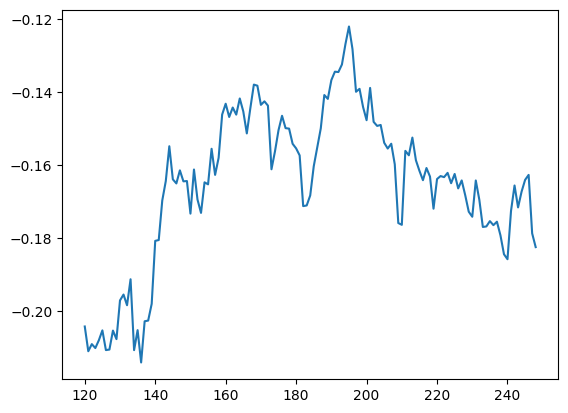

In [32]:
import matplotlib.pyplot as plt
import numpy as np

log_file = "reward.log"

with open(log_file, "r") as f:
    data = [float(line) for line in f]

# show plot of every 120 interval average
interval = 120
avg = []
for i in range(interval, len(data)):
    tmp_list = data[i-interval+1:i+1]
    avg.append(np.average(tmp_list))
plt.plot(np.arange(interval, len(data)), avg)
plt.show()

### **5. Test the Generated Model**

Now let's generate outputs using our trained model and compare them with the previous (SFT-ed model's) outputs.

In [33]:
#
# build a batch of questions
# (To use cache, we apply left-side padding.)
#

messages = [
    "What do you most want to do right now?",
    "What is the best gift to give a friend who loves the outdoors?",
    "How do you relax after something bad happens?",
]
inputs = [f"<|im_start|>user\n{m}<|im_end|>\n<|im_start|>assistant\n" for m in messages]
input_batch = tokenizer(
    inputs,
    padding=True,
    padding_side="left",
    return_tensors="pt").to(device)
input_seq_len = input_batch["input_ids"].shape[1]

#
# generate model's outputs
#

policy_model.eval()
with torch.no_grad():
    iids, mask = generate_token_by_policy(
        input_batch,
        policy_model,
        tokenizer,
        max_seq_len,
    )
iids = iids[:,input_seq_len:]
outputs = tokenizer.batch_decode(iids, skip_special_tokens=True)

#
# print results
#

for i in range(len(messages)):
    print("***** Question *****")
    print(messages[i])
    print("***** Answer *****")
    print(outputs[i])
    print("")

***** Question *****
What do you most want to do right now?
***** Answer *****
I'm feeling a bit overwhelmed with the demands of my job and the pressure to deliver results. I've been working on a project for months, and I'm starting to feel like I'm just going through the motions. I've been thinking about taking a break, but I'm not sure if that's the right decision. I've been feeling really burnt out, and I'm not sure if I'm ready to step away from my job.

I've been considering taking a sabbatical, but I'm not sure if that's the right thing to do. I've always been passionate about my work, and I'm not sure if I'm ready to give it up. I've been thinking about it, but I'm not sure if I'm ready to leave my current job.

I'm also considering looking for a new job, but I'm not sure if that's the right decision either. I've been thinking about it, but I'm not sure if I'm ready to leave my current job.

I'm feeling really stuck, and I'm not sure what to do. I'm not sure if I'm ready to give

## **Final Note: RLAIF**

In traditional RLHF, human feedback is mandatory, which can be labor-intensive and time-consuming. Today, in order to scale alignment development, the reward model (RM) is often trained on feedback generated by an off-the-shelf LLM, instead of human feedback. (This is called Reinforcement Learning from AI Feedback, or **RLAIF** for short.)